# はじめに

このノートでは、PyTorch Geometricを利用してグラフニューラルネットワークを構築することを目指す。最初はPyTorchの基礎からはじめ、グラフニューラルネットワーク、PyTorch Geometricと内容を進めていく。

今回は、PyTorch Geometricのイントロダクションで紹介されている下記のハンズオンを実行して理解を深める。

- [Introduction: Hands-on Graph Neural Networks](https://colab.research.google.com/drive/1h3-vJGRVloF5zStxL5I0rSy4ZUPNsjy8?usp=sharing#scrollTo=etxOsz8QIbMO)

下記はグラフニューラルネットワークを理解するための参考サイト。

- [グラフニューラルネットワーク | 佐藤 竜馬](https://www.amazon.co.jp/%E3%82%B0%E3%83%A9%E3%83%95%E3%83%8B%E3%83%A5%E3%83%BC%E3%83%A9%E3%83%AB%E3%83%8D%E3%83%83%E3%83%88%E3%83%AF%E3%83%BC%E3%82%AF-%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E3%83%97%E3%83%AD%E3%83%95%E3%82%A7%E3%83%83%E3%82%B7%E3%83%A7%E3%83%8A%E3%83%AB%E3%82%B7%E3%83%AA%E3%83%BC%E3%82%BA-%E4%BD%90%E8%97%A4-%E7%AB%9C%E9%A6%AC/dp/4065347823)
- [グラフ深層学習のすゝめ。 - YouTube](https://www.youtube.com/watch?v=7rgXi3Xp6NI)
- [GCN — グラフ道場](https://yuya-s.github.io/GraphDojo/01GCN.html)
- [Tutorial 6: Basics of Graph Neural Networks](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/06-graph-neural-networks.html)
- [Static and Dynamic Attention: Implications for Graph Neural Networks](https://medium.com/data-science/static-and-dynamic-attention-implications-for-graph-neural-networks-eda0d9d7b60a)
- [CS224W | Home](https://web.stanford.edu/class/cs224w/index.html)
- [nn.labml.ai/ja/graphs](https://nn.labml.ai/#:~:text=%E2%9C%A8%20Graph%20Neural%20Networks)


## グラフ作成

In [1]:
import torch
from torch_geometric.data import Data

グラフを作成する。グラフは頂点とエッジから構成されるため、まずはエッジを作成することでグラフを作成する。ここでは各頂点が他の頂点と接続しているようなグラフを作成する。グラフにはエッジが3つしかないが、エッジの両方向を考慮するには6つのエッジを定義する必要がある。

In [2]:
edge_from = torch.tensor([0, 0, 1, 1, 2, 2], dtype=torch.long)
edge_to__ = torch.tensor([1, 2, 0, 2, 0, 1], dtype=torch.long)
edge_index = torch.stack([edge_from, edge_to__], dim=0)
edge_index

tensor([[0, 0, 1, 1, 2, 2],
        [1, 2, 0, 2, 0, 1]])

各頂点は、特徴量と正解ラベルを持つこともできるので、特徴量と正解ラベルを作成する。そして、`Data`クラスを利用して、エッジ情報、特徴量、正解ラベルをまとめたグラフデータを作成する。

- `data.x`: 特徴量行列`[num_nodes, num_node_features]`
- `data.y`: トレーニング対象となるターゲット。頂点レベルのターゲット`[num_nodes, *]`、または、グラフレベルのターゲット`[1, *]`
- `data.edge_index`: COOフォーマット。エッジ情報をもつ。`[2, num_edges]`。
- `data.edge_attr`: エッジ特徴マトリックス`[num_edges, num_edge_features]`。
- `data.pos`: ノード位置行列`[num_nodes, num_dimensions]`。

In [3]:
x = torch.tensor([[0, 1], [2, 3], [4, 5]], dtype=torch.long)
y = torch.tensor([10, 20, 30], dtype=torch.long)
data = Data(x=x, y=y, edge_index=edge_index)
data

Data(x=[3, 2], edge_index=[2, 6], y=[3])

`Data`クラスのプロパティを確認することで、グラフの情報を確認することができる。

In [4]:
print(f"EdgeIndex: \n{data.edge_index}")
print(f"X: \n{data.x}")
print(f"Y: \n{data.y}")

EdgeIndex: 
tensor([[0, 0, 1, 1, 2, 2],
        [1, 2, 0, 2, 0, 1]])
X: 
tensor([[0, 1],
        [2, 3],
        [4, 5]])
Y: 
tensor([10, 20, 30])


他にも、グラフの情報を確認することができ、頂点数、エッジ数、特徴量の数、無向グラフなのか、独立した頂点はあるか、自己ループを持つのかなどを確認できる。

In [5]:
print(f"NumOfNodes: {data.num_nodes}")
print(f"NumOfEdges: {data.num_edges}")
print(f"NumOfFeatures: {data.num_features}")
print(f"IsUndirected: {data.is_undirected()}")
print(f"IsDirected: {data.is_directed()}")
print(f"HasIsolated: {data.has_isolated_nodes()}")
print(f"HasSelfLoops: {data.has_self_loops()}")

NumOfNodes: 3
NumOfEdges: 6
NumOfFeatures: 2
IsUndirected: True
IsDirected: False
HasIsolated: False
HasSelfLoops: False


グラフを可視化するためには、`to_networkx`関数と`networkx`を利用する。

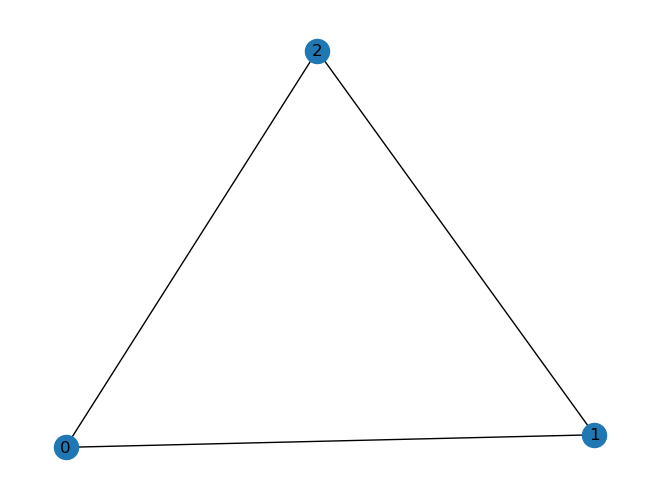

In [6]:
from torch_geometric.utils import to_networkx
import networkx as nx

nx_G = to_networkx(data, to_undirected=True)
nx.draw(nx_G, with_labels=True)

例えば、このノートの最終的な目的はグラフニューラルネットワークを利用して、ボートレースの着順予測モデルを作ることなので、ボートレースをグラフとして可視化すると以下のようになる。

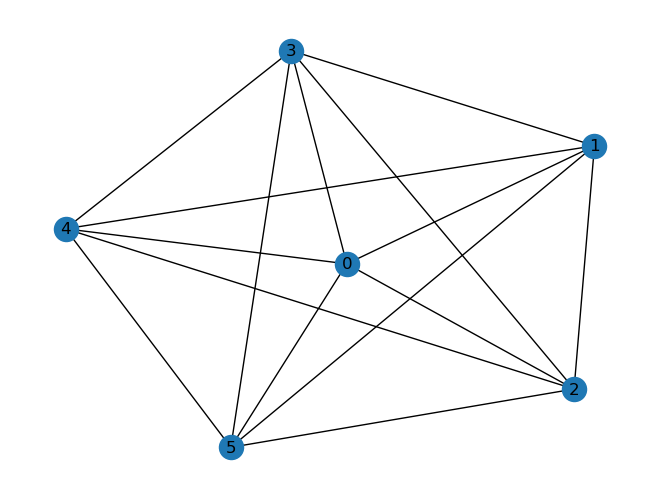

In [7]:
num_boats = 6  # 1R に 6艇

# 例: 全ノード完全グラフ（自分自身は除く）
edge_from_list = []
edge_to_list = []
for i in range(num_boats):
    for j in range(num_boats):
        if i == j:
            continue
        edge_from_list.append(i)
        edge_to_list.append(j)


edge_index = torch.tensor([edge_from_list, edge_to_list], dtype=torch.long)
num_nodes = int(edge_index.max()) + 1  # 0始まりのとき
data = Data(edge_index=edge_index, num_nodes=num_nodes)

nx_G = to_networkx(data, to_undirected=True)
nx.draw(nx_G, with_labels=True)

## グラフニューラルネットワーク

ここからは、PyTorch Geometricのイントロダクションで紹介されている下記のハンズオンに沿って、グラフニューラルネットワークを構築してみる。前のノートにおいても、グラフニューラルネットワークの基礎をまとめているが、ここでも簡単にまとめておく。

- [Introduction: Hands-on Graph Neural Networks](https://colab.research.google.com/drive/1h3-vJGRVloF5zStxL5I0rSy4ZUPNsjy8?usp=sharing#scrollTo=etxOsz8QIbMO)

グラフニューラルネットワークは、メッセージパッシング方式に従って実現される。graph $\mathcal{G} = (\mathcal{V}, \mathcal{E})$における特徴量$\mathbf{x}_v^{(\ell)}$は、それぞれの近傍頂点集合$\mathcal{N}(v)$から局所的な情報を集約し、反復的に更新する。

$$
\mathbf{x}_v^{(\ell + 1)} = f^{(\ell + 1)}_{\theta} \left( \mathbf{x}_v^{(\ell)}, \left\{ \mathbf{x}_w^{(\ell)} : w \in \mathcal{N}(v) \right\} \right)
$$

PyTorch Geometricには、いくつかのサンプルグラフも用意されている。ここでは`karate_club`データセットを利用する。このデータセットは大学の空手クラブのソーシャルネットワークを表すデータセット。各ノードはクラブのメンバーを表し、各エッジはクラブのメンバー2人の間のつながりを表す。このデータセットでは、2人の指導者間の口論の後、空手クラブがいくつかのグループに分裂し、分裂後のグループ識別子が`y`として保存されている。


In [8]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
data = dataset[0]
print(f"NumOfNodes: {data.num_nodes}")
print(f"NumOfEdges: {data.num_edges}")
print(f"NumOfFeatures: {data.num_features}")
print(f"IsUndirected: {data.is_undirected()}")
print(f"IsDirected: {data.is_directed()}")
print(f"HasIsolated: {data.has_isolated_nodes()}")
print(f"HasSelfLoops: {data.has_self_loops()}")

NumOfNodes: 34
NumOfEdges: 156
NumOfFeatures: 34
IsUndirected: True
IsDirected: False
HasIsolated: False
HasSelfLoops: False


In [9]:
print(f"key: \n{data.keys}")
print(f"EdgeIndex: \n{data.edge_index}")
print(f"X: \n{data.x}")
print(f"Y: \n{data.y}")
print(f"TrainMask: \n{data.train_mask}")

key: 
<bound method BaseData.keys of Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])>
EdgeIndex: 
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
        [ 1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 17, 19, 21, 31,  0,  2,
          3,  7, 13, 17, 19, 21, 30,  0,  1,  3,  7,  8,  9, 13, 27, 28, 32,  0,
          1,  2,  7

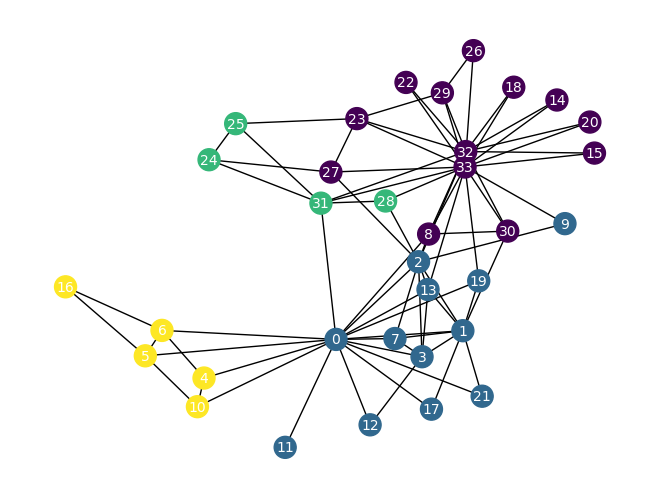

In [10]:
nx_G = to_networkx(data, to_undirected=True)
nx.draw(
    nx_G,
    with_labels=True,
    node_color=data.y,
    node_size=250,
    font_size=10,
    font_color="w",
)

`edge_index`をもう少し深堀りしてみる。この表現は **COO 形式 (座標形式)** として知られており、スパース行列の表現によく使用される。Pytorch Geometricは、隣接情報を隣接行列$\mathbf{A} \in \{ 0, 1 \}^{|\mathcal{V}| \times |\mathcal{V}|}$で保持する代わりに、グラフをスパースに表現する。これは$\mathbf{A}$ 内の非ゼロである座標、値のみを保持することを意味する。要するに、隣接行列では0が多くなってしまい、効率が悪くなる。また、Pytorch Geometricは有向グラフと無向グラフを区別せず、無向グラフを`edge_index` のすべてのエントリに逆エッジが存在する有向グラフの特殊なケースとして扱う。



In [11]:
edge_index = data.edge_index
print(edge_index.t())

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

空手データセットに対して、シンプルなGCNレイヤーを使用して、グラフニューラルネットワークを構築する。`__init__`でモデルを構成する部品を初期化する。`forward`の中で、ネットワークの計算の流れを定義する。ここでは、3つの畳み込み層を重ねている、これは、頂点の3ホップ近傍から特徴量の情報を集約することを意味する。また、GCNConv層は特徴量の次元を`34->4->4->2->4 classes`のように削減する。各層では`tanh`関数を活性化関数として利用している。

In [12]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.

        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h


model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


1層目のこの部分は、重み行列$W_{1}$(34,4)、特徴量行列$X^{(0)}$(34,34)の畳み込みを計算する。結果$X^{(1)}= X^{(0)}W_{1}$は(34,4)の行列になる。

```python
self.conv1 = GCNConv(dataset.num_features, 4)
```

$$
\begin{aligned}
In &: X^{(0)} \in \mathbb{ R }^{34 \times 34} \\
Weight &: W_{1} \in \mathbb{ R }^{34 \times 4} \\
Out &: H^{(1)} \in \mathbb{ R }^{34 \times 4} \\
\end{aligned}
$$

2層目のこの部分は、重み行列$W_{2}$(4,4)、特徴量行列$H^{(1)}$(34,4)の畳み込みを計算する。結果$H^{(2)}=H^{(1)}W_{2}$は(34,4)の行列になる。


```python
self.conv2 = GCNConv(4, 4)
```

$$
\begin{aligned}
In &: H^{(1)} \in \mathbb{ R }^{34 \times 4} \\
Weight &: W_{2} \in \mathbb{ R }^{4 \times 4} \\
Out &: H^{(2)} \in \mathbb{ R }^{34 \times 4} \\
\end{aligned}
$$


3層目のこの部分は、重み行列$W_{3}$(4,2)、特徴量行列$H^{(2)}$(34,4)の畳み込みを計算する。結果$H^{(3)}=H^{(2)}W_{3}$は(34,2)の行列になる。


```python
self.conv3 = GCNConv(4, 2)
```

$$
\begin{aligned}
In &: H^{(2)} \in \mathbb{ R }^{34 \times 4} \\
Weight &: W_{3} \in \mathbb{ R }^{4 \times 2} \\
Out &: H^{(3)} \in \mathbb{ R }^{34 \times 2} \\
\end{aligned}
$$

最後のこの部分は、重み行列$W_{c}$(2,4)、特徴量行列$H^{(3)}$(34,2)の畳み込みを計算する。結果$out=H^{(3)}W_{c}$は(34,4)の行列になる。


```python
self.classifier = Linear(2, dataset.num_classes)
```

$$
\begin{aligned}
In &: H^{(3)} \in \mathbb{ R }^{34 \times 2} \\
Weight &: W_{c} \in \mathbb{ R }^{2 \times 4} \\
Out &: Z \in \mathbb{ R }^{34 \times 4} \\
\end{aligned}
$$


まとめると下記のとおりに計算している。3層目の出力で(34,2)の行列になっているが、これは各頂点を「2次元ベクトル」に圧縮した埋め込みで、つまり、平面上の点になる。空手のコミュニティが2次元平面で分離している様子を可視化できる。そこから、最後は4次元にもどし、空手データセットは4クラスの分類問題なので、各クラスごとに確率を計算する。

$$
\begin{aligned}
H^{(1)} &= \tanh\left(\hat{A} X^{(0)} W_1\right) - 34 \times 4 \\
H^{(2)} &= \tanh\left(\hat{A} H^{(1)} W_2\right) - 34 \times 4 \\
H^{(3)} &= \tanh\left(\hat{A} H^{(2)} W_3\right) - 34 \times 2 \\
Z &= H^{(3)} W_c - 34 \times 4
\end{aligned}
$$

In [13]:
model = GCN()
# returnがout, hなので、hに3層目の結果が入る
_, h = model(data.x, data.edge_index)
print(f"Embedding shape: {list(h.shape)}")

Embedding shape: [34, 2]


ノードの埋め込みを可視化しておく。モデルの重みはランダムに初期化されており、重みを学習する前でさえ、モデルはグラフのコミュニティ構造に非常によく似たクラスタを生成する。

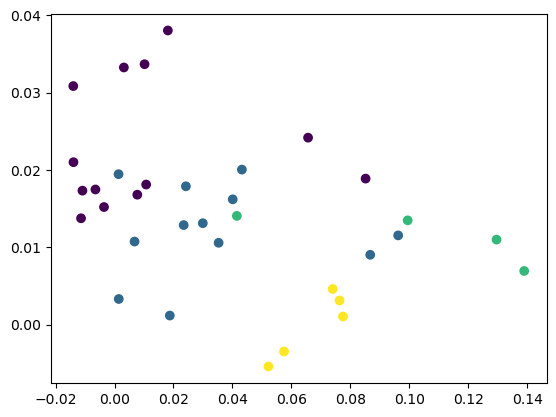

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(
    h[:, 0].detach().cpu().numpy(),
    h[:, 1].detach().cpu().numpy(),
    c=data.y.detach().cpu().numpy(),
)

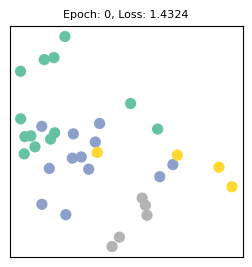

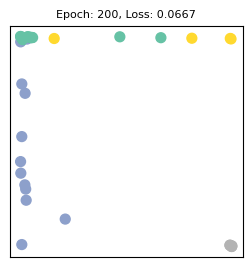

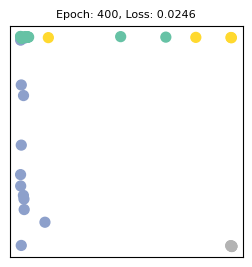

In [15]:
model = GCN()
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer.


def visualize_embedding(h, color, epoch=None, loss=None):
    plt.figure(figsize=(3, 3))
    plt.xticks([])
    plt.yticks([])
    h = h.detach().cpu().numpy()
    plt.scatter(h[:, 0], h[:, 1], s=50, c=color, cmap="Set2")
    if epoch is not None and loss is not None:
        plt.title(f"Epoch: {epoch}, Loss: {loss.item():.4f}", fontsize=8)
    plt.show()


def train(data):
    optimizer.zero_grad()  # Clear gradients.
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(
        out[data.train_mask], data.y[data.train_mask]
    )  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, h


for epoch in range(401):
    loss, h = train(data)
    if epoch % 200 == 0:
        visualize_embedding(h, color=data.y, epoch=epoch, loss=loss)